# README
1. AUSPEX is a BBN instrumnet control package. 
2. We are using SRS SR865 lockin + RenSci piezo stage. Both connected via ethernet with static IP addresses
3. AUSPEX has a number of 'import visa' scattered across the source code; needs to be updated to 'import pyvisa as visa'. Best to push these changes or fork the repo and have a local copy.

In [38]:
%load_ext autoreload
%autoreload 2
from auspex.instruments import SR865
from rensci import RenSciDriver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
PIEZO_HOST = "172.31.255.99"
PIEZO_PORT = 6002

In [40]:
lockin = SR865()
lockin.connect('TCPIP0::172.31.255.252')

print(f"Connected to {lockin.name} \n\n X= {lockin.x}, Y = {lockin.y}")

xyz = RenSciDriver(PIEZO_HOST, PIEZO_PORT)
xyz.connect()

Connected to SR865 Lockin Amplifier 

 X= 0.0028484030627, Y = -4.1422052163e-05
Connected to 172.31.255.99:6002


In [41]:
xyz.goPosition(1, -4.4)
xyz.goPosition(2, -1.15)
xyz.goPosition(3, -3.23)
r=[]
for i in range(100):
    xyz.goStepsForward(1, steps=10)
    r.append(lockin.r)

KeyboardInterrupt: 

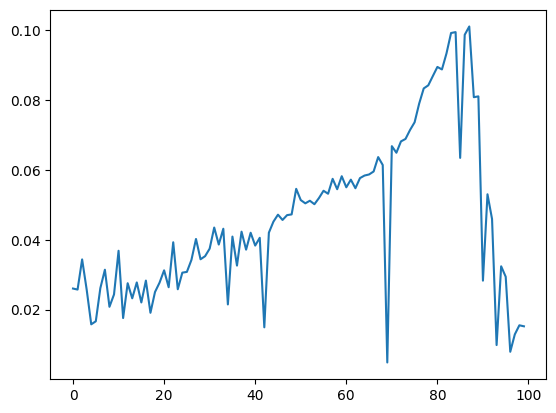

In [18]:
import matplotlib.pyplot as plt
plt.plot(r)

In [33]:
xyz.goPosition(1, -4)


{'id': '41834', 'jsonrpc': '2.0', 'result': True}

In [31]:
r=[]

for i in range(600):
    xyz.goStepsForward(1, steps=10)
    r.append(lockin.r)

Reconnecting to server
Disconnecting from server
Connected to 172.31.255.99:6002


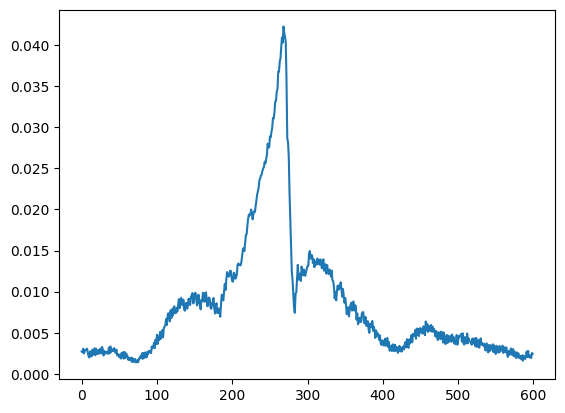

In [32]:
plt.plot(r)

In [42]:
xyz.getPosition(1)

AttributeError: 'RenSciDriver' object has no attribute 'getPosition'